In [1]:
# import all the necessary libraries
import pysindy as ps
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
# The van der pol oscillator system
def simple_harmonic_oscillator(t, x, zeta=0.1, omega_n = 1, Fhat=0.4, omega=1.4):
    return [x[1], 
           -2*zeta*omega_n*x[1] - omega_n ** 2 * x[0] + Fhat * np.sin(x[2]),
           omega]

In [3]:
# generate the data for testing
start = 0
end = 100
step = 0.01
t_span = [start, end]
x0 = [0.3, 0.1, 0]
sol = solve_ivp(simple_harmonic_oscillator, t_span, x0, dense_output=True)
t = np.arange(start, end+step/10, step)
x = sol.sol(t).T

In [4]:
# The feature names of the columns of y
feature_names = ['x1', 'x2', 'omega t']

# Which feature library to use
# Here I'm using a polynomial library that contains all combinations of the columns upto the degree 3

# functions = [lambda x : np.cos(x), lambda x: np.sin(x)]
# function_names = [lambda x : "cos(" + str(x) +")", lambda x: "sin(" + str(x) +")"]
# lib_custom = CustomLibrary(library_functions=functions, 
#                            function_names=function_names)
# lib_custom.fit(x)
# lib_custom.transform(x)

feature_library = ps.PolynomialLibrary(degree=3) + ps.FourierLibrary()
# feature_library = ps.PolynomialLibrary(degree=3) + lib_custom

# Differentiation method
differentiation_method = ps.FiniteDifference(order=2)


# Optimizer
opt = ps.STLSQ(threshold=0.1)
# opt = ps.SR3(threshold=0.1,thresholder="L1")
# opt = ps.FROLS(max_iter=5,alpha=0.5)
# opt = ps.SSR()

# Building the model
model=ps.SINDy(differentiation_method=differentiation_method,
               feature_library = feature_library,
               feature_names=feature_names, 
              optimizer=opt)


# Fitting the model to the training data
model.fit(x,t=t)

# Print the model
model.print()



(x1)' = 1.000 x2
(x2)' = -1.006 x1 + -0.200 x2 + 0.006 sin(1 x1) + 0.400 sin(1 omega t)
(omega t)' = 1.400 1


In [5]:
# Simulate the identified system 
sim = model.simulate(x0,t=t)

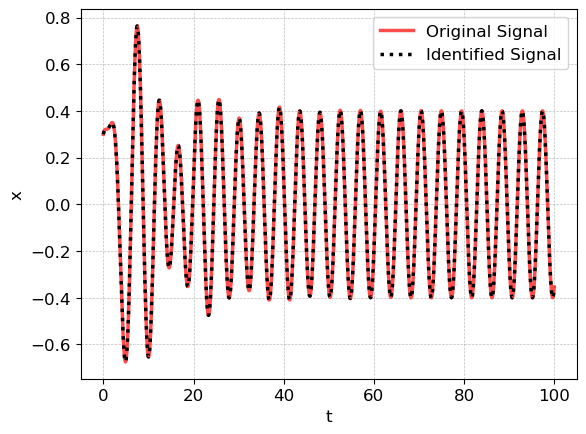

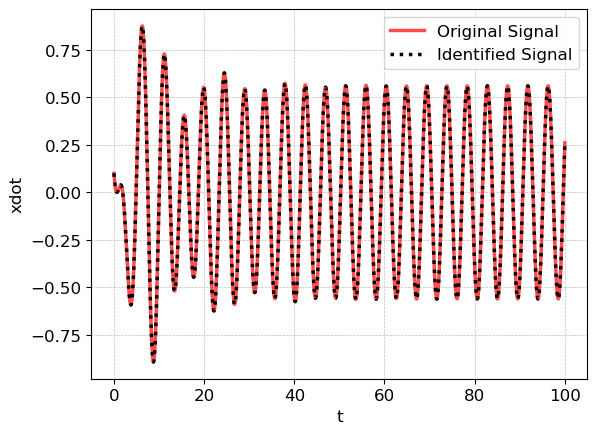

In [6]:
# plot the solution

plt.rcParams.update({'font.size': 12})

# displacement
plt.plot(t,x[:,0],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,0],'k:',linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("x")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('disp_vdp_f.pdf', format='pdf', dpi=300)
plt.show()


# velocity
plt.plot(t,x[:,1],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,1],'k:',linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("xdot")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('vel_vdp_f.pdf', format='pdf', dpi=300)
plt.show()

In [7]:
R2 = r2_score(x[:,0],sim[:,0])
MSE = mean_squared_error(x[:,0],sim[:,0])

print(f"R2 score: {R2}")
print(f"Mean Squared Error: {MSE}")

R2 score: 0.9999998886657101
Mean Squared Error: 1.036635055635845e-08
